### EXPERIMENT NO. 10
### Character, Digit, or Face Classification using Convolutional
### Neural Networks (CNNs)


### NAME       : Abhigyan Dubey
### CUID       : CU24250059
### COURSE     : BTECH CSE
### SECTION    : B
### ROLL NO.   : 02


### AIM

### To design, train, and evaluate a Convolutional Neural Network
### (CNN) for handwritten digit classification using the MNIST
### dataset and analyze its performance using suitable metrics.


 STEP 1: IMPORT REQUIRED LIBRARIES

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

STEP 2: LOAD THE MNIST DATASET

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Testing images :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Testing images : (10000, 28, 28)


STEP 3: PREPROCESS THE DATA

In [ ]:
# Normalize pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# Split training data into training and validation data
x_val = x_train[-10000:]
y_val = y_train[-10000:]

x_train = x_train[:-10000]
y_train = y_train[:-10000]

print("Training data after split:", x_train.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)

Training data after split: (50000, 28, 28, 1)
Validation data: (10000, 28, 28, 1)
Testing data: (10000, 28, 28, 1)


STEP 4: DISPLAY SAMPLE IMAGES

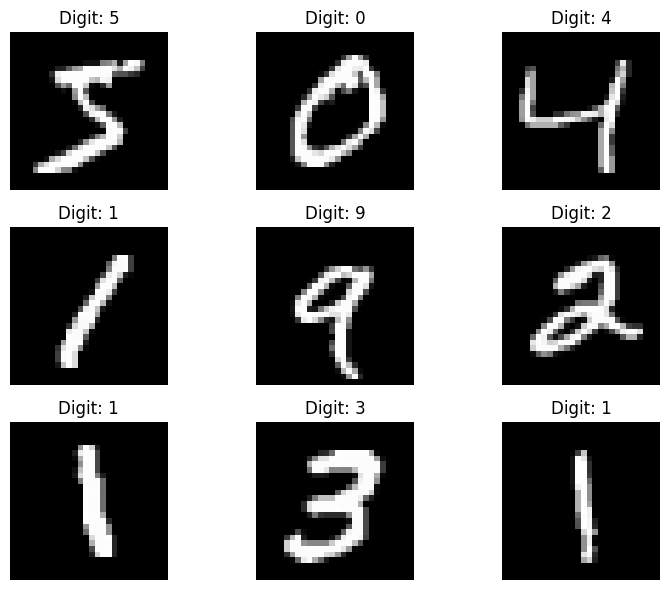

In [ ]:
plt.figure(figsize=(8, 6))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

STEP 5: DESIGN THE CNN MODEL

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(10, activation="softmax")
])
# Display model architecture
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 STEP 6: COMPILE THE MODEL

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

 STEP 7: TRAIN THE CNN MODEL

In [ ]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=5,
    batch_size=128
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.9148 - loss: 0.2800 - val_accuracy: 0.9777 - val_loss: 0.0742
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.9747 - loss: 0.0797 - val_accuracy: 0.9846 - val_loss: 0.0559
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9824 - loss: 0.0572 - val_accuracy: 0.9879 - val_loss: 0.0462
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 96ms/step - accuracy: 0.9869 - loss: 0.0438 - val_accuracy: 0.9887 - val_loss: 0.0385
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step - accuracy: 0.9889 - loss: 0.0359 - val_accuracy: 0.9906 - val_loss: 0.0344


STEP 8: DISPLAY TRAINING AND VALIDATION ACCURACY

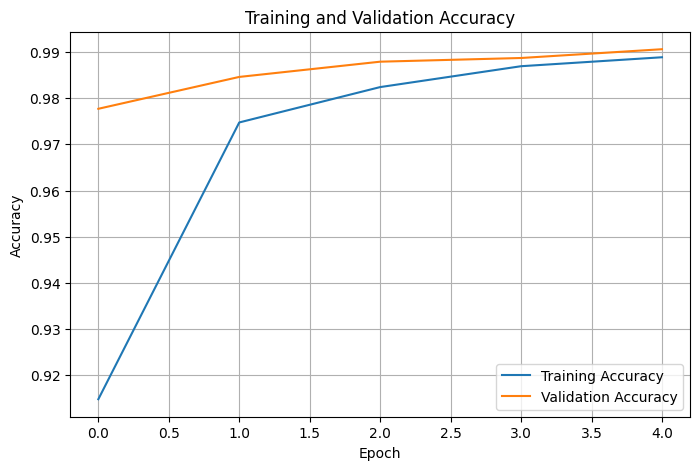

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

STEP 9: DISPLAY TRAINING AND VALIDATION LOSS

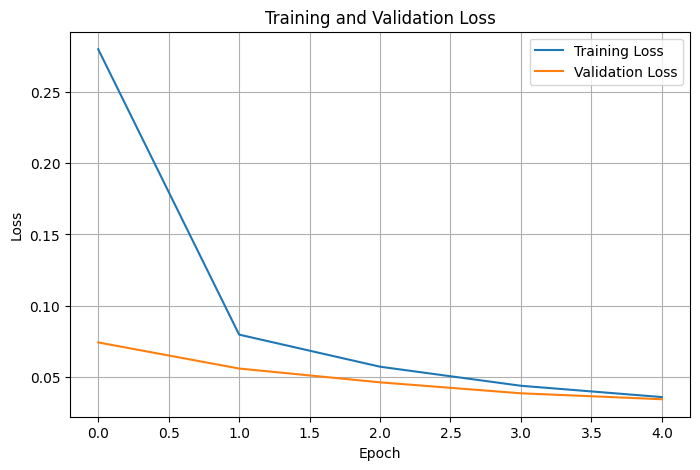

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

STEP 10: EVALUATE MODEL ON TEST DATA

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)


Test Accuracy: 0.9908000230789185
Test Loss: 0.027723412960767746


STEP 11: MAKE PREDICTIONS

In [ ]:
predictions = model.predict(x_test, verbose=0)

y_pred = np.argmax(predictions, axis=1)

 STEP 12: CALCULATE PRECISION, RECALL AND F1-SCORE

In [ ]:
   report = classification_report(
    y_test,
    y_pred,
    digits=4
)

print("\nClassification Report:")
print(report)


Classification Report:
              precision    recall  f1-score   support

           0     0.9899    0.9959    0.9929       980
           1     0.9921    0.9938    0.9930      1135
           2     0.9904    0.9952    0.9928      1032
           3     0.9901    0.9931    0.9916      1010
           4     0.9949    0.9919    0.9934       982
           5     0.9844    0.9877    0.9860       892
           6     0.9937    0.9885    0.9911       958
           7     0.9922    0.9854    0.9888      1028
           8     0.9938    0.9908    0.9923       974
           9     0.9861    0.9851    0.9856      1009

    accuracy                         0.9908     10000
   macro avg     0.9907    0.9907    0.9907     10000
weighted avg     0.9908    0.9908    0.9908     10000



 STEP 13: CONFUSION MATRIX

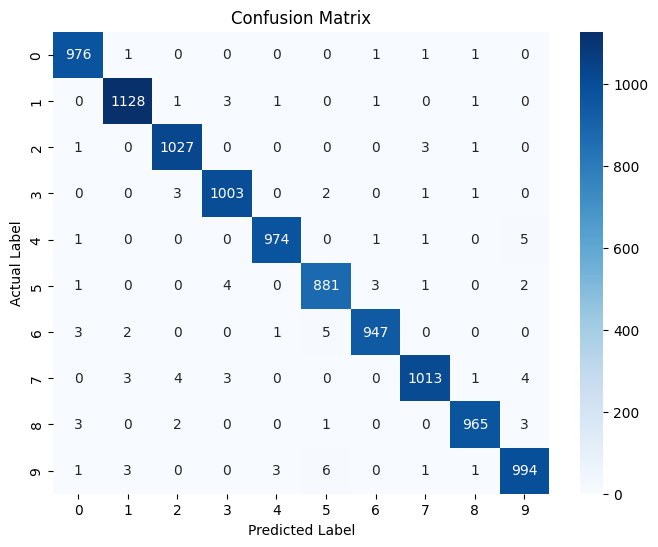

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

STEP 14: PREDICTION ON UNSEEN IMAGES

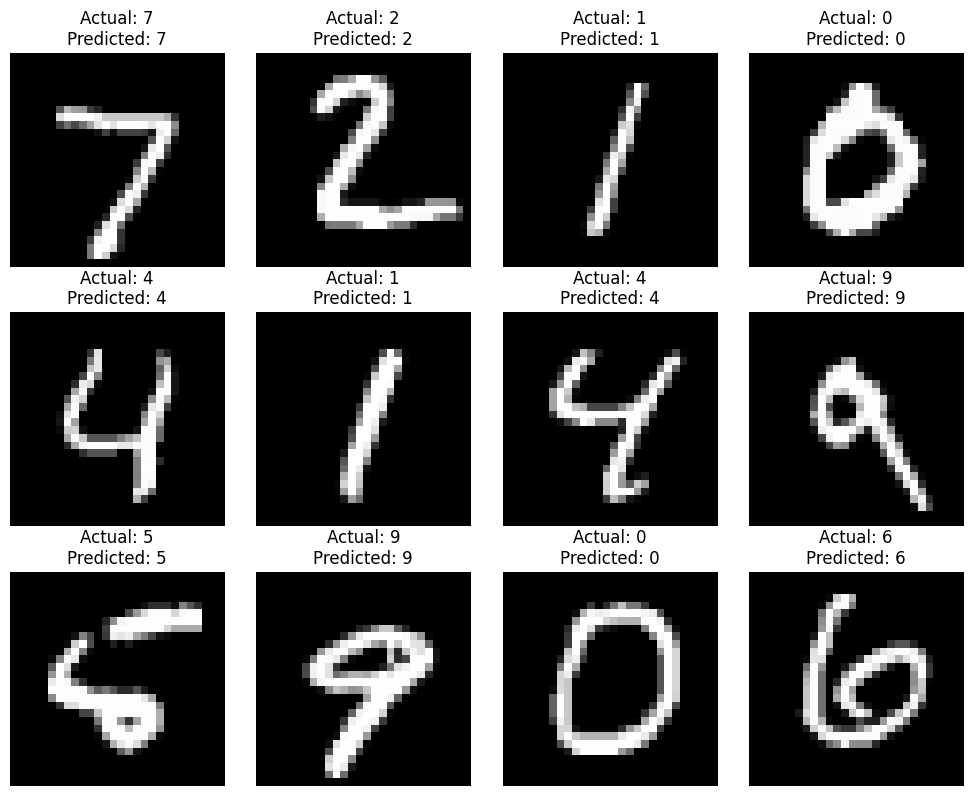

In [ ]:
plt.figure(figsize=(10, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(
        x_test[i].reshape(28, 28),
        cmap="gray"
    )

    predicted_digit = y_pred[i]
    actual_digit = y_test[i]

    plt.title(
        "Actual: " + str(actual_digit) +
        "\nPredicted: " + str(predicted_digit)
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

STEP 15: FIND MISCLASSIFIED IMAGES


Number of misclassified images: 92


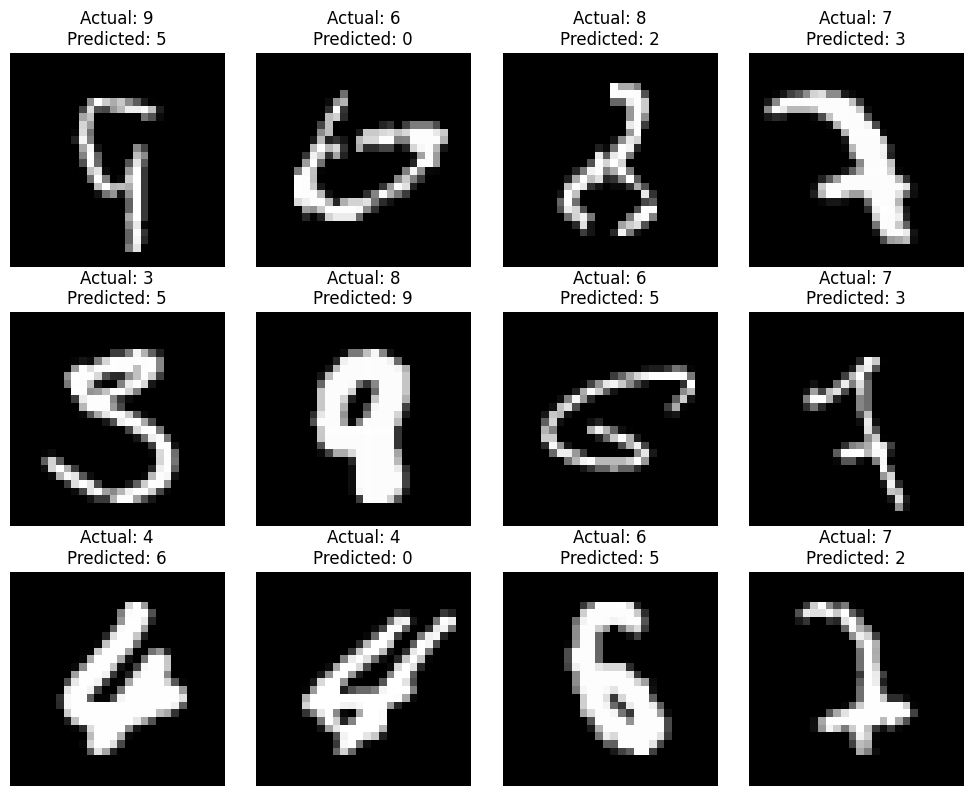

In [ ]:
wrong_indices = np.where(y_pred != y_test)[0]

print("\nNumber of misclassified images:", len(wrong_indices))

plt.figure(figsize=(10, 8))

for i in range(min(12, len(wrong_indices))):

    index = wrong_indices[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        x_test[index].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        "Actual: " + str(y_test[index]) +
        "\nPredicted: " + str(y_pred[index])
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


# QUESTIONS AND ANSWERS


 Q1. What is image classification? How does it differ from object
 detection and image segmentation?

 Answer:
 Image classification assigns one or more class labels to an image.
Object detection identifies objects and also provides their locations
 using bounding boxes. Image segmentation assigns a class to individual
 pixels or regions of an image.

 Q2. Explain the architecture and working principle of a CNN.

 Answer:
 A CNN normally contains convolutional layers, activation functions,
 pooling layers, flattening, fully connected layers, and an output layer.
 Convolutional layers extract image features, pooling reduces feature
 dimensions, and fully connected layers perform classification.

 Q3. What is the role of Convolutional Layers, Pooling Layers, and
 Fully Connected Layers in a CNN?

 Answer:
 Convolutional layers detect features such as edges and shapes.
 Pooling layers reduce the size of feature maps and retain important
 information. Fully connected layers use the extracted features to
 perform the final classification.

 Q4. Why is image normalization performed before training a deep
 learning model?

 Answer:
 Image normalization scales pixel values to a smaller range such as
 0 to 1. It helps the neural network train faster and makes the
 optimization process more stable.

 Q5. Explain the purpose of activation functions such as ReLU and
 Softmax in CNNs.

 Answer:
 ReLU introduces non-linearity into the network and is commonly used
 in hidden layers. Softmax converts the final output values into
 probabilities for the different classes.

 Q6. What is a Confusion Matrix? How is it used to evaluate
 classification performance?

 Answer:
 A confusion matrix is a table showing actual classes against predicted
 classes. It shows correct predictions and different types of
 misclassification for each class.

 Q7. Differentiate between Accuracy, Precision, Recall, and F1-Score.

 Answer:
 Accuracy is the proportion of all predictions that are correct.
 Precision measures how many predicted positive samples are actually
 positive. Recall measures how many actual positive samples are detected.
 F1-Score is the harmonic mean of precision and recall.

 Q8. Compare traditional feature-based image classification methods such as SIFT/HOG + SVM with CNN-based classification.

 Answer:
 SIFT/HOG + SVM requires manually designed or extracted features before
 classification. CNNs automatically learn useful features directly from
 training images. CNNs generally require more computational resources
and training data but can learn complex features automatically.

 Q9. Mention five real-world applications of CNN-based image
 classification.

 Answer:
 1. Handwritten digit recognition
 2. Facial recognition
 3. Medical image analysis
 4. Biometric authentication
 5. Intelligent document processing

 Q10. How can Data Augmentation, Transfer Learning, and Hyperparameter
 Tuning improve deep learning image classification?

 Answer:
 Data augmentation creates variations of training images and can reduce
 overfitting. Transfer learning uses knowledge learned from an existing
 model and can reduce training requirements. Hyperparameter tuning helps
 select suitable learning rate, batch size, number of layers, epochs,
 and other training parameters.

